# E-commerce Customer Segmentation & Revenue Strategy

**Portfolio project | Python, SQL, RFM analysis, K-means clustering**

Source: [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)  
License: CC BY 4.0 | Transaction period: Dec. 2010-Dec. 2011

## tl;dr

After cleaning 541,909 invoice lines, the analysis covers
**4,338 customers**, **18,532 orders**,
and **£8,911,408** in revenue. The Champions segment contains
**16.6% of customers** and generates
**64.9% of cleaned revenue**, making retention
the first priority. At Risk customers should receive a controlled reactivation test.

## Context & Methods

**Decision:** Which customer segments should the retailer prioritize for retention,
reactivation, and growth campaigns?

The analysis cleans invoice-level transactions, calculates revenue KPIs with SQL,
builds customer-level Recency-Frequency-Monetary (RFM) features, and applies K-means
clustering. Segment names are assigned from observed cluster profiles rather than
from demographic assumptions.

### Key Assumptions

- Cancelled invoices, non-positive quantities/prices, and rows without CustomerID
  are excluded from sales and RFM calculations.
- The analysis snapshot date is one day after the last observed transaction.
- K=4 is used for a compact, campaign-ready segmentation; the silhouette score is
  reported as a diagnostic, not as proof that four segments are uniquely correct.
- Revenue is descriptive and does not include product cost, margin, or marketing cost.

## Data

In [1]:
from pathlib import Path
import json
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "data").exists():
    repository_project = PROJECT_DIR / "project_1_retail_customer_segmentation"
    if repository_project.exists():
        PROJECT_DIR = repository_project
DATA_PATH = PROJECT_DIR / "data" / "Online Retail.xlsx"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

BLUE = "#2F6BFF"
BLUE_DARK = "#163B77"
BLUE_LIGHT = "#AFC9FF"
GOLD = "#D8A227"
INK = "#20242B"
GREY = "#8A929E"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CDD3DA",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 10,
    "axes.titleweight": "bold",
})

In [2]:
transactions_raw = pd.read_excel(DATA_PATH, engine="openpyxl")
transactions_raw["InvoiceDate"] = pd.to_datetime(transactions_raw["InvoiceDate"])

source_profile = pd.Series({
    "Rows": len(transactions_raw),
    "Columns": transactions_raw.shape[1],
    "Start date": transactions_raw["InvoiceDate"].min().date(),
    "End date": transactions_raw["InvoiceDate"].max().date(),
    "Unique invoices": transactions_raw["InvoiceNo"].nunique(),
    "Rows missing CustomerID": transactions_raw["CustomerID"].isna().sum(),
}, name="Source profile")
source_profile

Rows                           541909
Columns                             8
Start date                 2010-12-01
End date                   2011-12-09
Unique invoices                 25900
Rows missing CustomerID        135080
Name: Source profile, dtype: object

In [3]:
cancelled_mask = transactions_raw["InvoiceNo"].astype(str).str.startswith("C")
valid_mask = (
    ~cancelled_mask
    & transactions_raw["CustomerID"].notna()
    & (transactions_raw["Quantity"] > 0)
    & (transactions_raw["UnitPrice"] > 0)
)

transactions = transactions_raw.loc[valid_mask].copy()
transactions["CustomerID"] = transactions["CustomerID"].astype(int).astype(str)
transactions["Revenue"] = transactions["Quantity"] * transactions["UnitPrice"]
transactions["InvoiceMonth"] = transactions["InvoiceDate"].dt.to_period("M").astype(str)

quality_summary = pd.DataFrame({
    "check": [
        "Raw rows",
        "Cancelled invoice rows",
        "Rows missing CustomerID",
        "Clean sales rows",
        "Clean unique invoices",
        "Clean unique customers",
    ],
    "value": [
        len(transactions_raw),
        int(cancelled_mask.sum()),
        int(transactions_raw["CustomerID"].isna().sum()),
        len(transactions),
        transactions["InvoiceNo"].nunique(),
        transactions["CustomerID"].nunique(),
    ],
})
quality_summary

,check,value
0,Raw rows,541909
1,Cancelled invoice rows,9288
2,Rows missing CustomerID,135080
3,Clean sales rows,397884
4,Clean unique invoices,18532
5,Clean unique customers,4338


## Results

In [4]:
db_path = OUTPUT_DIR / "retail_analysis.sqlite"
if db_path.exists():
    db_path.unlink()

with sqlite3.connect(db_path) as connection:
    transactions.to_sql("transactions", connection, index=False, if_exists="replace")

    kpi_sql = '''
    SELECT
        ROUND(SUM(Revenue), 2) AS revenue_gbp,
        COUNT(DISTINCT InvoiceNo) AS orders,
        COUNT(DISTINCT CustomerID) AS customers,
        ROUND(SUM(Revenue) / COUNT(DISTINCT InvoiceNo), 2) AS average_order_value_gbp
    FROM transactions
    '''
    kpis = pd.read_sql_query(kpi_sql, connection).iloc[0]

    monthly_sql = '''
    SELECT
        InvoiceMonth AS month,
        ROUND(SUM(Revenue), 2) AS revenue_gbp,
        COUNT(DISTINCT InvoiceNo) AS orders,
        COUNT(DISTINCT CustomerID) AS active_customers
    FROM transactions
    GROUP BY InvoiceMonth
    ORDER BY InvoiceMonth
    '''
    monthly_revenue = pd.read_sql_query(monthly_sql, connection)

    country_sql = '''
    SELECT
        Country AS country,
        ROUND(SUM(Revenue), 2) AS revenue_gbp,
        COUNT(DISTINCT InvoiceNo) AS orders,
        COUNT(DISTINCT CustomerID) AS customers
    FROM transactions
    GROUP BY Country
    HAVING COUNT(DISTINCT CustomerID) >= 5
    ORDER BY revenue_gbp DESC
    LIMIT 10
    '''
    country_summary = pd.read_sql_query(country_sql, connection)

kpis.to_frame("value")

,value
revenue_gbp,"8,911,407.90"
orders,"18,532.00"
customers,"4,338.00"
average_order_value_gbp,480.87


In [5]:
snapshot_date = transactions["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

rfm = (
    transactions.groupby("CustomerID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)
rfm["Recency"] = (snapshot_date - rfm["LastPurchase"].dt.normalize()).dt.days

model_features = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])
scaled_features = StandardScaler().fit_transform(model_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
rfm["Cluster"] = kmeans.fit_predict(scaled_features)
silhouette = silhouette_score(scaled_features, rfm["Cluster"])

cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("CustomerID", "nunique"),
        MedianRecency=("Recency", "median"),
        MedianFrequency=("Frequency", "median"),
        MedianMonetary=("Monetary", "median"),
        Revenue=("Monetary", "sum"),
    )
)
cluster_profile["ValueScore"] = (
    cluster_profile["MedianFrequency"].rank(pct=True)
    + cluster_profile["MedianMonetary"].rank(pct=True)
    - cluster_profile["MedianRecency"].rank(pct=True)
)

remaining = set(cluster_profile.index)
champions_cluster = cluster_profile["ValueScore"].idxmax()
remaining.remove(champions_cluster)
at_risk_cluster = cluster_profile.loc[list(remaining), "MedianRecency"].idxmax()
remaining.remove(at_risk_cluster)
loyal_cluster = (
    cluster_profile.loc[list(remaining), ["MedianFrequency", "MedianMonetary"]]
    .rank(pct=True)
    .sum(axis=1)
    .idxmax()
)
remaining.remove(loyal_cluster)
developing_cluster = remaining.pop()

cluster_labels = {
    champions_cluster: "Champions",
    loyal_cluster: "Loyal",
    developing_cluster: "Developing",
    at_risk_cluster: "At Risk",
}
rfm["Segment"] = rfm["Cluster"].map(cluster_labels)

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "nunique"),
        MedianRecency=("Recency", "median"),
        MedianFrequency=("Frequency", "median"),
        MedianMonetary=("Monetary", "median"),
        Revenue=("Monetary", "sum"),
    )
    .reset_index()
)
segment_summary["CustomerShare"] = segment_summary["Customers"] / segment_summary["Customers"].sum()
segment_summary["RevenueShare"] = segment_summary["Revenue"] / segment_summary["Revenue"].sum()
segment_summary = segment_summary.sort_values("Revenue", ascending=False)

rfm.to_csv(OUTPUT_DIR / "customer_segments.csv", index=False)
segment_summary.to_csv(OUTPUT_DIR / "segment_summary.csv", index=False)
monthly_revenue.to_csv(OUTPUT_DIR / "monthly_revenue.csv", index=False)
country_summary.to_csv(OUTPUT_DIR / "country_summary.csv", index=False)
segment_summary

,Segment,Customers,MedianRecency,MedianFrequency,MedianMonetary,Revenue,CustomerShare,RevenueShare
1,Champions,720,9.00,10.00,"3,726.08","5,786,787.92",0.17,0.65
3,Loyal,1162,54.00,4.00,"1,353.74","2,106,281.36",0.27,0.24
0,At Risk,1579,183.00,1.00,300.42,"556,006.67",0.36,0.06
2,Developing,877,19.00,2.00,450.84,"462,331.95",0.20,0.05


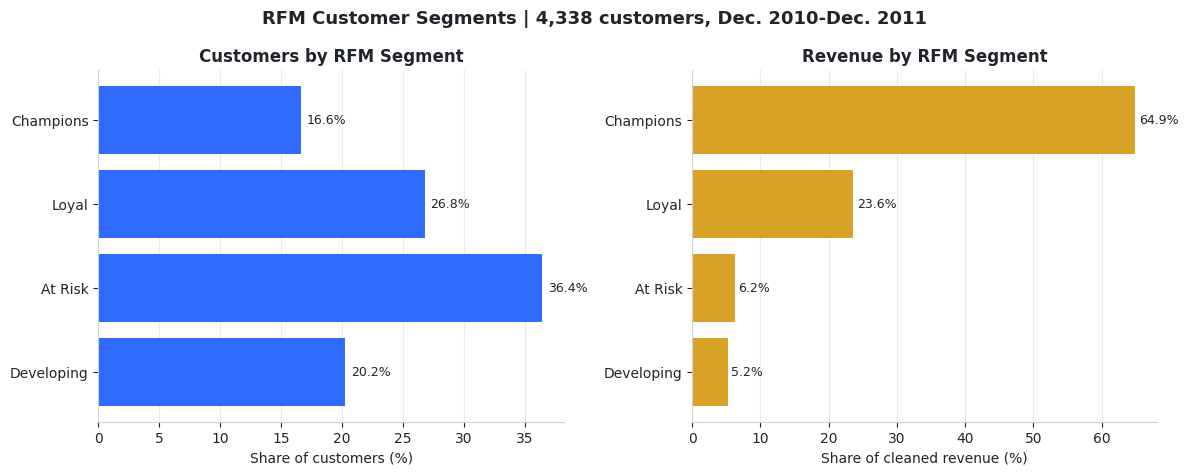

In [6]:
plot_data = segment_summary.sort_values("RevenueShare")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].barh(plot_data["Segment"], plot_data["CustomerShare"] * 100, color=BLUE)
axes[0].set_title("Customers by RFM Segment")
axes[0].set_xlabel("Share of customers (%)")
axes[0].grid(axis="x", color="#E8EBEF", linewidth=0.8)
for i, value in enumerate(plot_data["CustomerShare"] * 100):
    axes[0].text(value + 0.5, i, f"{value:.1f}%", va="center", fontsize=9)

axes[1].barh(plot_data["Segment"], plot_data["RevenueShare"] * 100, color=GOLD)
axes[1].set_title("Revenue by RFM Segment")
axes[1].set_xlabel("Share of cleaned revenue (%)")
axes[1].grid(axis="x", color="#E8EBEF", linewidth=0.8)
for i, value in enumerate(plot_data["RevenueShare"] * 100):
    axes[1].text(value + 0.5, i, f"{value:.1f}%", va="center", fontsize=9)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

fig.suptitle(
    f"RFM Customer Segments | {len(rfm):,} customers, Dec. 2010-Dec. 2011",
    fontsize=13,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(CHART_DIR / "rfm_segment_mix.png", dpi=180, bbox_inches="tight")
plt.show()

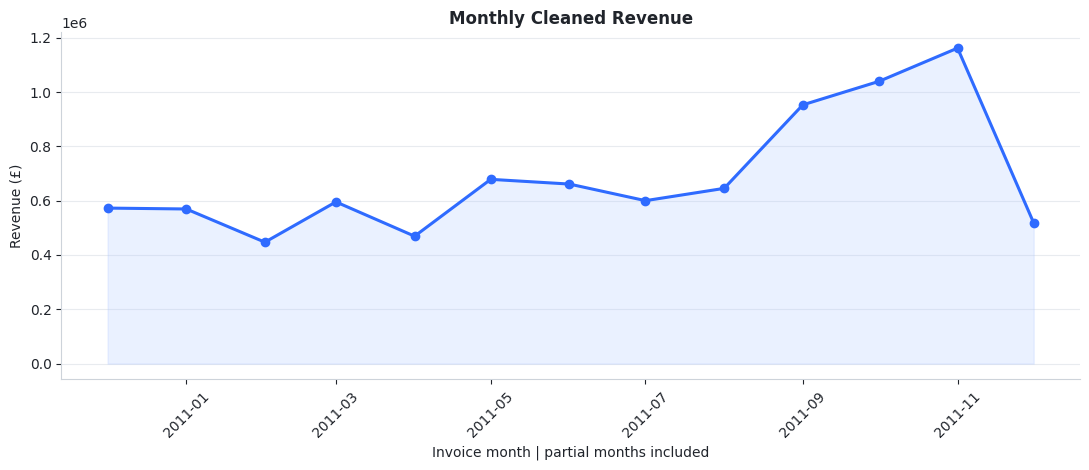

In [7]:
monthly_plot = monthly_revenue.copy()
monthly_plot["month"] = pd.to_datetime(monthly_plot["month"])

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(
    monthly_plot["month"],
    monthly_plot["revenue_gbp"],
    color=BLUE,
    marker="o",
    linewidth=2.2,
)
ax.fill_between(
    monthly_plot["month"],
    monthly_plot["revenue_gbp"],
    color=BLUE_LIGHT,
    alpha=0.25,
)
ax.set_title("Monthly Cleaned Revenue")
ax.set_ylabel("Revenue (£)")
ax.set_xlabel("Invoice month | partial months included")
ax.grid(axis="y", color="#E8EBEF", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=45)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(CHART_DIR / "monthly_revenue.png", dpi=180, bbox_inches="tight")
plt.show()

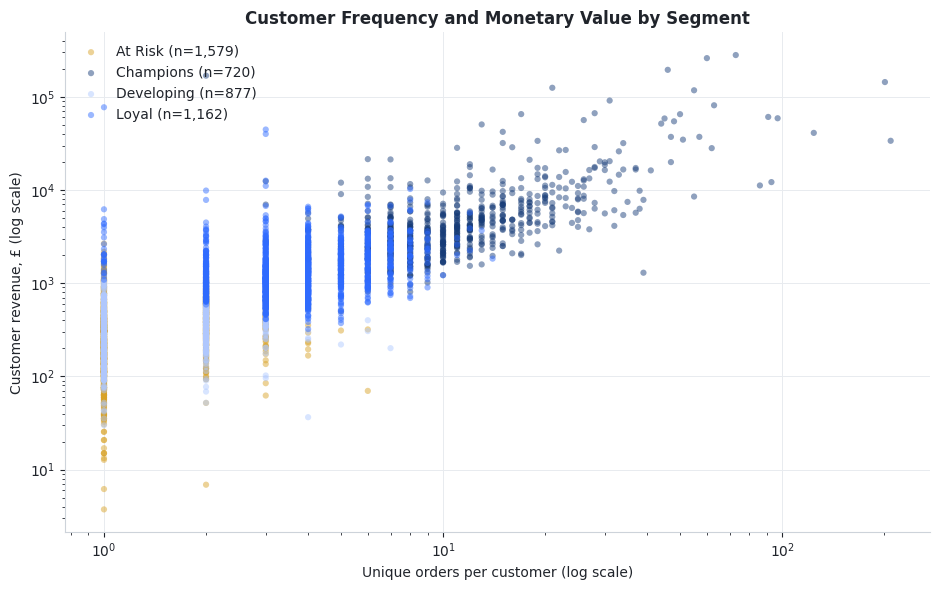

In [8]:
palette = {
    "Champions": BLUE_DARK,
    "Loyal": BLUE,
    "Developing": BLUE_LIGHT,
    "At Risk": GOLD,
}

fig, ax = plt.subplots(figsize=(9.5, 6))
for segment, group in rfm.groupby("Segment"):
    ax.scatter(
        group["Frequency"],
        group["Monetary"],
        s=20,
        alpha=0.48,
        label=f"{segment} (n={len(group):,})",
        color=palette[segment],
        edgecolors="none",
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Customer Frequency and Monetary Value by Segment")
ax.set_xlabel("Unique orders per customer (log scale)")
ax.set_ylabel("Customer revenue, £ (log scale)")
ax.grid(color="#E8EBEF", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(CHART_DIR / "frequency_monetary_scatter.png", dpi=180, bbox_inches="tight")
plt.show()

In [9]:
champions = segment_summary.loc[segment_summary["Segment"] == "Champions"].iloc[0]
at_risk = segment_summary.loc[segment_summary["Segment"] == "At Risk"].iloc[0]
peak_month = monthly_revenue.loc[monthly_revenue["revenue_gbp"].idxmax()]

validation_checks = {
    "segment_customer_count_matches": int(segment_summary["Customers"].sum()) == int(rfm["CustomerID"].nunique()),
    "segment_revenue_matches": bool(np.isclose(segment_summary["Revenue"].sum(), transactions["Revenue"].sum())),
    "customer_share_sums_to_one": bool(np.isclose(segment_summary["CustomerShare"].sum(), 1)),
    "revenue_share_sums_to_one": bool(np.isclose(segment_summary["RevenueShare"].sum(), 1)),
    "no_nonpositive_sales_rows": bool(((transactions["Quantity"] > 0) & (transactions["UnitPrice"] > 0)).all()),
}
assert all(validation_checks.values()), validation_checks

summary = {
    "raw_rows": int(len(transactions_raw)),
    "clean_rows": int(len(transactions)),
    "customers": int(kpis["customers"]),
    "orders": int(kpis["orders"]),
    "revenue_gbp": float(kpis["revenue_gbp"]),
    "average_order_value_gbp": float(kpis["average_order_value_gbp"]),
    "silhouette_score": float(silhouette),
    "champions_customers": int(champions["Customers"]),
    "champions_customer_share": float(champions["CustomerShare"]),
    "champions_revenue_share": float(champions["RevenueShare"]),
    "at_risk_customers": int(at_risk["Customers"]),
    "at_risk_revenue_share": float(at_risk["RevenueShare"]),
    "peak_month": str(peak_month["month"]),
    "peak_month_revenue_gbp": float(peak_month["revenue_gbp"]),
    "validation_checks": validation_checks,
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
summary

{'raw_rows': 541909,
 'clean_rows': 397884,
 'customers': 4338,
 'orders': 18532,
 'revenue_gbp': 8911407.9,
 'average_order_value_gbp': 480.87,
 'silhouette_score': 0.3355470584455458,
 'champions_customers': 720,
 'champions_customer_share': 0.16597510373443983,
 'champions_revenue_share': 0.64936853775962,
 'at_risk_customers': 1579,
 'at_risk_revenue_share': 0.06239268553181471,
 'peak_month': '2011-11',
 'peak_month_revenue_gbp': 1161817.38,
 'validation_checks': {'segment_customer_count_matches': True,
  'segment_revenue_matches': True,
  'customer_share_sums_to_one': True,
  'revenue_share_sums_to_one': True,
  'no_nonpositive_sales_rows': True}}

## Takeaways

- Protect the **Champions** segment with early access, loyalty benefits, and
  replenishment reminders; it combines recent activity, repeat purchasing, and
  high customer value.
- Run a measured reactivation test for **At Risk** customers instead of discounting
  the full base. Use holdouts and incremental revenue to judge whether the campaign
  creates value.
- Develop newer customers through second-purchase journeys and product recommendations.
- Treat November/December comparisons carefully because the first and last months in
  the source are partial periods.